# Lesson 2 : Multi Head Attention 

"Why one attention isn't enough. And what happens when you run several at once.

# The Problem First :

Go back to lesson 5 of stage 2. We built self attention with one set of Q,K,V.

lets stress test it with a harder sentence :

__"The tired animal didn't cross the street because it was too scared"__

For the word "it", there isn't just one relationship to capture — there are several, all at once:

* Coreference: "it" = "animal" → needs to attend to "animal"
* Reason: "it" was "scared" → needs to attend to "scared"
* Grammar: "it" is the subject of "was" → needs to attend to "was"

A single attention head produces one weighted average. One set of attention weights. One blended output. It has to squeeze all three of these relationships into a single compromise — like trying to answer three different questions with one averaged answer.

Analogy: Imagine looking at a photo through only one colored lens at a time — a lens that highlights color, OR one that highlights texture, OR one that highlights depth, but never all three together. You'd lose information every time you had to pick just one lens.

Multi-head attention gives the model several lenses simultaneously.

# What Multi-Head Attention actually does 

The idea is simple:

Instead of one big attention computation, split it into several smaller, parallel attention computations- each with its own learned Q,K,V - then combine the results.

Concretely with d_model=512 and num_heads=8
1. Split the 512 dimensional space into 8 chunks of 64 dimensions each (__d_k=d_model/n_heads__)
2. Each head gets its own learned weight matrices - so each head can specialize in a different type of pattern 
3. All 8 heads compute attention parallel,independently 
4. Concatenate all 8 outputs back into 512-dimensional vector.
5. Pass through one final linear layer to blend information across heads

Why smaller per-head dimensions and not full-size for each head? Compute budget. If every head used the full 512 dimensions, you'd multiply your compute cost by 8. By splitting 512 into 8 pieces of 64, the total compute stays roughly the same as one full attention operation — but now you get 8 different "views" instead of 1.

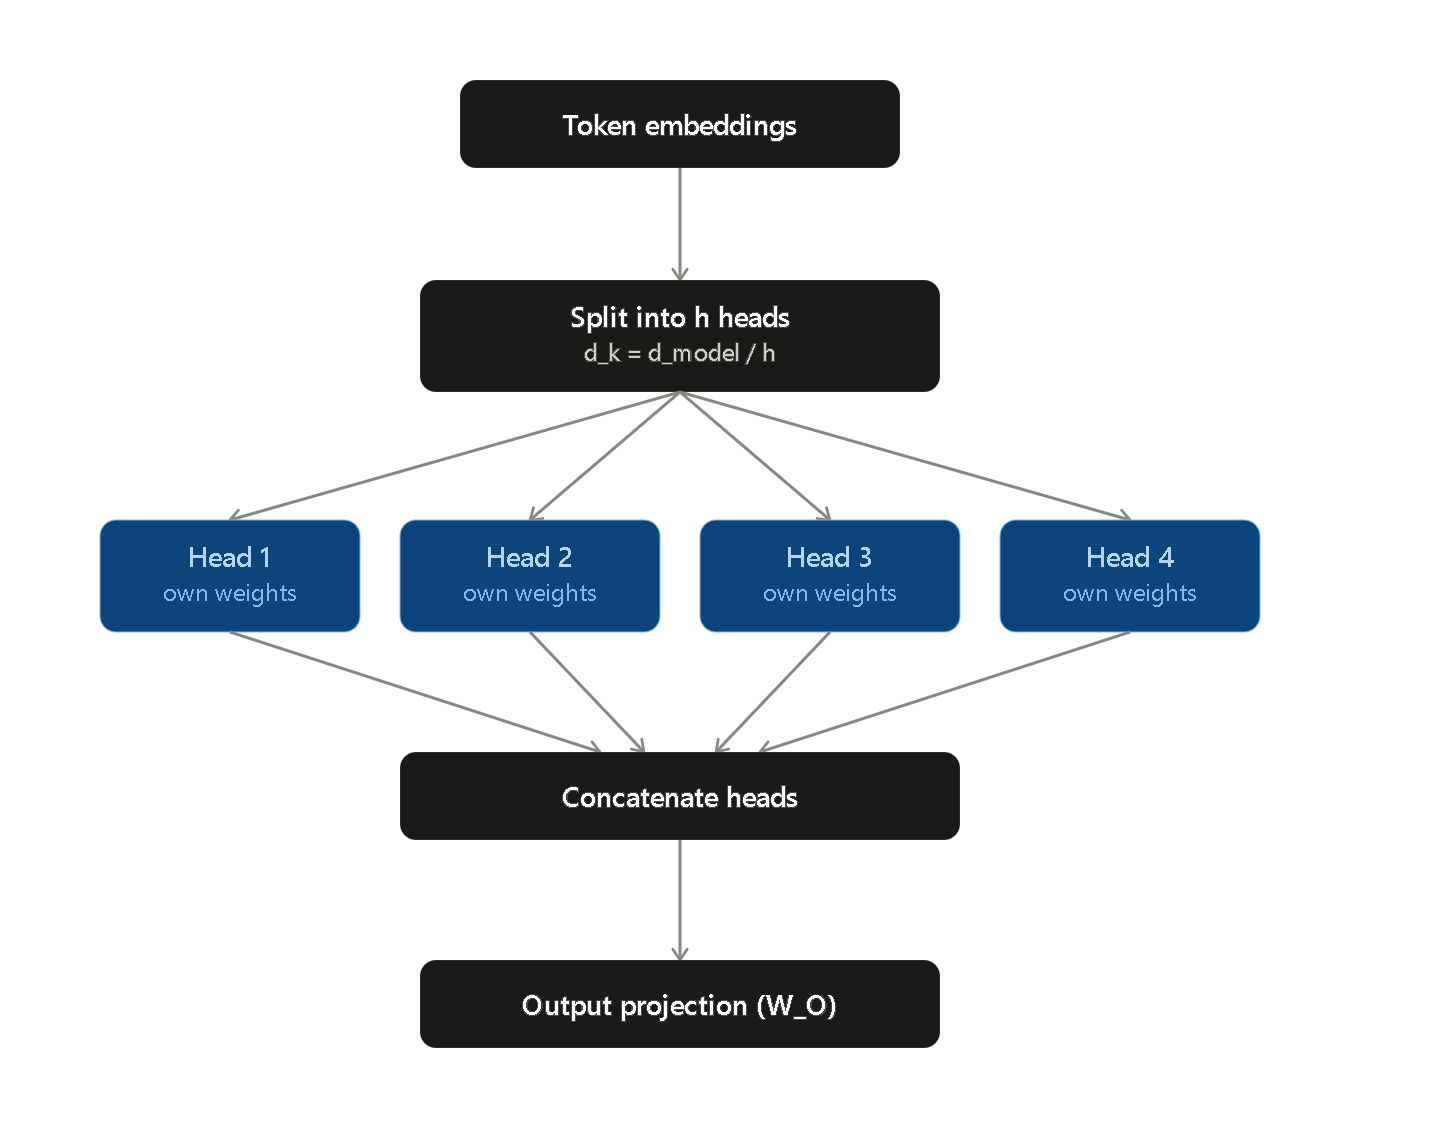

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class MultiHeadAttention(nn.Module):
    def __init__(self,d_model,num_heads):
        super().__init__()
        assert d_model%num_heads== 0,"d_model must be divisible by num_heads"
        self.d_model=d_model
        self.num_heads=num_heads
        self.d_k = d_model//num_heads
        
        # These are only 4 weight matrices in the whole layer
        self.W_q=nn.Linear(d_model,d_model)
        self.W_k=nn.Linear(d_model,d_model)
        self.W_v=nn.Linear(d_model,d_model)
        self.W_o=nn.Linear(d_model,d_model)

    def split_heads(self,x,batch_size):
        x= x.view(batch_size,-1,self.num_heads,self.d_k)
        return x.transpose(1,2)

    def forward(self, x,mask=None):
        batch_size,seq_len,_=x.shape
        Q = self.split_heads(self.W_q(x), batch_size)
        K = self.split_heads(self.W_k(x),batch_size)
        V = self.split_heads(self.W_v(x),batch_size)

         # Scaled dot-product attention — ALL heads computed at once via batched matmul
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)

        if mask is not None:
            scores=scores.masked_fill(mask==0,float("-inf"))
        
        weights=F.softmax(scores,dim=-1)
        head_outputs=torch.matmul(weights,V)

        # Bring back together
        head_outputs=head_outputs.transpose(1,2).contiguous()
        concat=head_outputs.view(batch_size,seq_len,self.d_model)

        output=self.W_o(concat)
        return output,weights




Input shape:  torch.Size([1, 11, 64])
Output shape: torch.Size([1, 11, 64])
Weights shape (batch, heads, seq, seq): torch.Size([1, 4, 11, 11])


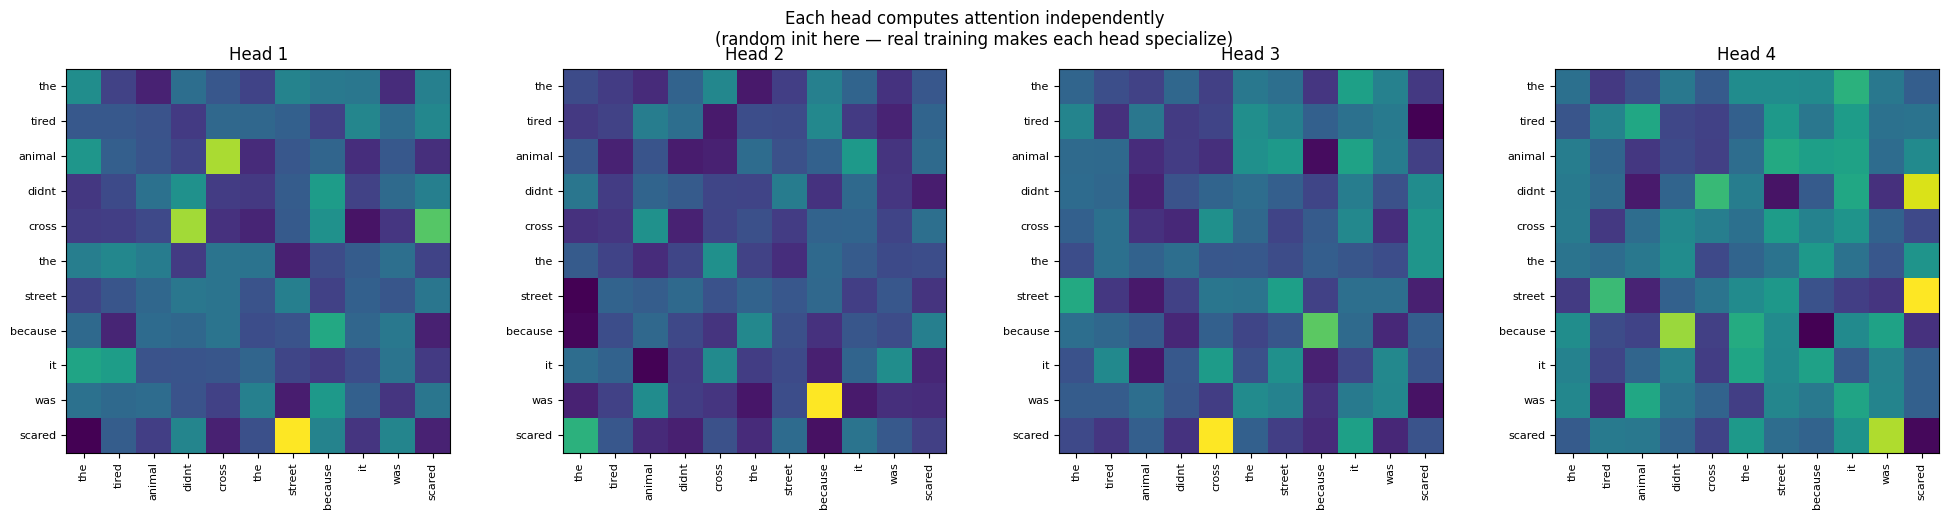

In [ ]:
torch.manual_seed(42)
sentence  = ["the", "tired", "animal", "didnt", "cross","the", "street", "because", "it", "was", "scared"]
seq_len   = len(sentence)
d_model   = 64
num_heads = 4

mha = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
X   = torch.randn(1, seq_len, d_model)     # batch=1, random "embeddings"

output, weights = mha(X)
print("Input shape: ", X.shape)
print("Output shape:", output.shape)
print("Weights shape (batch, heads, seq, seq):", weights.shape)

# --- Visualize what each head attends to ---
fig, axes = plt.subplots(1, num_heads, figsize=(5*num_heads, 5))
for h in range(num_heads):
    ax = axes[h]
    w  = weights[0, h].detach().numpy()
    ax.imshow(w, cmap='viridis')
    ax.set_xticks(range(seq_len)); ax.set_yticks(range(seq_len))
    ax.set_xticklabels(sentence, rotation=90, fontsize=8)
    ax.set_yticklabels(sentence, fontsize=8)
    ax.set_title(f"Head {h+1}")
plt.suptitle("Each head computes attention independently\n"
             "(random init here — real training makes each head specialize)")
plt.tight_layout()
plt.savefig("multihead_untrained.png", dpi=150)
plt.show()

In [5]:
def count_params(model):
     return sum(p.numel() for p in model.parameters())

mha_1  = MultiHeadAttention(d_model=64, num_heads=1)   # = single-head attention
mha_4  = MultiHeadAttention(d_model=64, num_heads=4)
mha_8  = MultiHeadAttention(d_model=64, num_heads=8)

print("Params, 1 head: ", count_params(mha_1))
print("Params, 4 heads:", count_params(mha_4))
print("Params, 8 heads:", count_params(mha_8))
print("\n→ Identical parameter count. num_heads only changes HOW we")
print("  reshape and split the same W_Q, W_K, W_V, W_O matrices —")
print("  it doesn't add capacity, it restructures it into parallel views.")

Params, 1 head:  16640
Params, 4 heads: 16640
Params, 8 heads: 16640

→ Identical parameter count. num_heads only changes HOW we
  reshape and split the same W_Q, W_K, W_V, W_O matrices —
  it doesn't add capacity, it restructures it into parallel views.


# Casual Multi-Head Attention


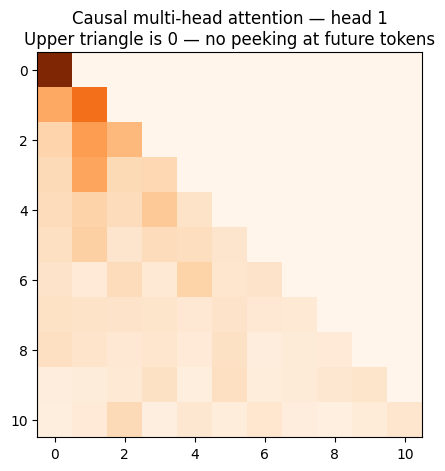

In [8]:
torch.manual_seed(42)
d_model = 64
num_heads = 4
seq_len = 11  # Length of your 11-word sentence
X = torch.randn(1, seq_len, d_model)  #  X tensor
class CasualMultiHeadattention(nn.Module):
    def __init__(self,d_model,num_heads):
        super().__init__()
        self.mha=MultiHeadAttention(d_model,num_heads)
        
    def forward(self,x):
        seq_len=x.size(1)
        casual_mask=torch.tril(torch.ones(seq_len,seq_len)).bool()
        casual_mask=casual_mask.unsqueeze(0).unsqueeze(0)
        return self.mha(x,mask=casual_mask)
    
casual_mha=CasualMultiHeadattention(d_model=64,num_heads=4)
out,w=casual_mha(X)
fig,ax=plt.subplots(figsize=(5,5))
ax.imshow(w[0,0].detach().numpy(),cmap='Oranges')
ax.set_title("Causal multi-head attention — head 1\nUpper triangle is 0 — no peeking at future tokens")
plt.savefig("casual_mha.png",dpi=150)
plt.show()




__Every one of GPT's attention layers is this class, stacked many times, with d_model around 768–12,288 and num_heads around 12–96 depending on model size.__

In [13]:
pytorch_mha=nn.MultiheadAttention(embed_dim=d_model,num_heads=num_heads,batch_first=True)
x2=torch.rand(1,seq_len,d_model)
attn_output, attn_weights = pytorch_mha(x2, x2, x2, average_attn_weights=False)

print("Output shape: ", attn_output.shape)   # (1, seq_len, d_model)
print("Weights shape:", attn_weights.shape)  # (1, num_heads, seq_len, seq_len)
print("\nNote: by default PyTorch AVERAGES weights across heads.")
print("Pass average_attn_weights=False to inspect each head separately.")

Output shape:  torch.Size([1, 11, 64])
Weights shape: torch.Size([1, 4, 11, 11])

Note: by default PyTorch AVERAGES weights across heads.
Pass average_attn_weights=False to inspect each head separately.


# The Evolution: Why Modern LLMs Changed This(MQA)&(GQA)

While Standard Multi-Head Attention (MHA) was the gold standard from 2017 ~ 2022 , modern open-weights LLMs like LLaMA 2/3, Mistral and Qwen no longer use pure MHA.    

__They use Grouped-Query Attention (GQA)__

## Why Did yhey Change it ?? (KV-Cache Bottleneck)

When an LLM generates text during inference, it produces tokens one by one.To avoid recompution the attention scores for all previous words over and over again,engines saves previously computed Key(K) and Value(V) tensors in GPU Memory. Thsi is Called K-V Cache.

In standard MHA with 96 heads (like GPT-3), caching 96 separate Key matrices and 96 separate Value matrices for thousands of tokens consumes massive amounts of GPU RAM, often running out of memory before the compute chips even hit 50% utilization!

# The Architectural Spectrum 

| Attention Variant | How it Works | KV-Cache Memory | Models use in |
| :-----: | :-----: | :-----: | :-----: |
| Multi-Head (MHA) | Every head gets its own Query, Key, and Value matrices. | 100% (High Memory) | Original Transformer, BERT, GPT-2/3|
| Multi-Query (MQA) | Every head gets its own Query, but all heads share only 1 Key and 1 Value matrix!| ~1% to 5% (Tiny Memory) | PaLM, Falcon, StarCoder |
| Grouped-Query (GQA) | A middle ground: Heads are divided into groups (e.g., 32 Q heads share 8 K/V heads). | ~25% (Balanced) | LLaMA 2 & 3, Mistral 7B, Gemma |
